# WORKAHOLIC — BiLSTM Job Recommendation System

**CV-based Job Recommendation menggunakan Embedding + Bidirectional LSTM**  
Tim CC-26-PSU105 | Coding Camp 2026 powered by DBS Foundation
TIM AI : Syifa Cahya Maryana dan Ghina Muslimah

---

## Pipeline

| Step | Keterangan |
|------|------------|
| 1 | Setup environment |
| 2 | Load dataset (`cv_model_ready.csv`, `loker_clean.csv`, `df_salary.csv`) |
| 3 | EDA — Exploratory Data Analysis |
| 4 | Preprocessing & Tokenisasi |
| 5 | Build Model BiLSTM |
| 6 | Training dengan EarlyStopping |
| 7 | Evaluasi Model |
| 8 | Inference: prediksi kategori + rekomendasi lowongan |
| 9 | Estimasi Gaji (statistik dari df_salary) |
| 10 | Save artifacts |
| 11 | Flask API |

> **Model:** Embedding (dim=128) + 2× BiLSTM + Dense  
> **Salary:** Tidak butuh model terpisah — pakai statistik P25/Median/P75 dari `df_salary.csv`  
> **Input CV:** PDF atau teks langsung (tanpa OCR gambar)

## 1. Setup Environment

In [1]:
import sys, subprocess

packages = [
    'tensorflow', 'pandas', 'numpy', 'scikit-learn',
    'matplotlib', 'seaborn', 'pdfplumber', 'pypdf',
    'flask', 'flask-cors'
]

print('Installing dependencies...')
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', pkg],
        capture_output=True
    )
    status = 'OK  ' if result.returncode == 0 else 'FAIL'
    print(f'  [{status}] {pkg}')

from pathlib import Path
for folder in ['dataset', 'models', 'api']:
    Path(folder).mkdir(exist_ok=True)

print('\nSetup selesai.')

Installing dependencies...
  [OK  ] tensorflow
  [OK  ] pandas
  [OK  ] numpy
  [OK  ] scikit-learn
  [OK  ] matplotlib
  [OK  ] seaborn
  [OK  ] pdfplumber
  [OK  ] pypdf
  [OK  ] flask
  [OK  ] flask-cors

Setup selesai.


## 2. Load Dataset

Upload file berikut ke Colab (sidebar Files atau `files.upload()`):
- `cv_model_ready.csv` — 13.043 baris, kolom: `job_title`, `skills`, `education_program`, `job_title_std`
- `loker_clean.csv` — 241.820 lowongan
- `df_salary.csv` — 1.660 data gaji

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

def load_csv(filename, desc):
    """Load CSV dengan auto-detect encoding, cari di dataset/ atau folder kerja."""
    for root in [Path('dataset'), Path('.')]:
        p = root / filename
        if p.exists():
            for enc in ['utf-8', 'latin1', 'utf-8-sig']:
                try:
                    df = pd.read_csv(p, encoding=enc, low_memory=False)
                    print(f'  {desc}: {p} — {df.shape[0]:,} baris x {df.shape[1]} kolom')
                    return df
                except Exception:
                    continue
    raise FileNotFoundError(f'File tidak ditemukan: {filename}')

df_cv    = load_csv('cv_model_ready.csv', 'CV Dataset  ')
df_loker = load_csv('loker_clean.csv',    'Job Postings')
df_sal   = load_csv('df_salary.csv',      'Salary Data ')

# Buat kolom teks gabungan untuk training BiLSTM
# Menggabungkan: job_title asli + skills + education_program
df_cv['combined_text'] = (
    df_cv['job_title'].fillna('') + ' ' +
    df_cv['skills'].fillna('') + ' ' +
    df_cv['education_program'].fillna('')
)

print(f'\nKolom CV     : {list(df_cv.columns)}')
print(f'Kolom Loker  : {list(df_loker.columns)}')
print(f'Kolom Salary : {list(df_sal.columns)}')
print(f'\nKategori ({df_cv["job_title_std"].nunique()} kelas):')
print(df_cv['job_title_std'].value_counts().to_string())
print()
print('Sample combined_text:')
for i in range(3):
    print(f'  [{df_cv["job_title_std"].iloc[i]}] {df_cv["combined_text"].iloc[i][:80]}...')

  CV Dataset  : dataset/cv_model_ready.csv — 13,043 baris x 9 kolom
  Job Postings: dataset/loker_clean.csv — 241,820 baris x 13 kolom
  Salary Data : dataset/df_salary.csv — 1,660 baris x 12 kolom

Kolom CV     : ['job_title', 'skills', 'skill_count', 'exp_count', 'ability_count', 'education_program', 'ai_score', 'recruiter_decision', 'job_title_std', 'combined_text']
Kolom Loker  : ['jobTitle', 'companyName', 'description', 'employment', 'categoriesName', 'locations', 'salaryMin', 'salaryMax', 'salarycurrency', 'sellingPoints', 'salary_available', 'full_text', 'has_description']
Kolom Salary : ['jobTitle', 'categoriesName', 'locations', 'employment', 'salaryMin', 'salaryMax', 'salary_mid', 'main_category', 'main_location', 'salaryMin_scaled', 'salaryMax_scaled', 'salary_mid_scaled']

Kategori (16 kelas):
job_title_std
Backend Developer                 2317
Network & System Administrator    2120
Database Administrator            1872
Frontend Developer                1488
Project Mana

In [3]:
print('Mencoba memuat cv_model_ready.csv dengan path absolut:')
df_cv_absolute = pd.read_csv('/content/dataset/cv_model_ready.csv')
display(df_cv_absolute.head())

Mencoba memuat cv_model_ready.csv dengan path absolut:


,job_title,skills,skill_count,exp_count,ability_count,education_program,ai_score,recruiter_decision,job_title_std
0,AI Researcher,"tensorflow, nlp, pytorch",3.0,10,0.0,B.Sc,100,Hire,Data Scientist
1,Data Scientist,"deep learning, machine learning, python, sql",4.0,10,0.0,MBA,100,Hire,Data Scientist
2,Cybersecurity Analyst,"ethical hacking, cybersecurity, linux",3.0,1,0.0,MBA,70,Hire,Cybersecurity Analyst
3,AI Researcher,"python, pytorch, tensorflow",3.0,7,0.0,B.Tech,95,Hire,Data Scientist
4,Software Engineer,"sql, react, java",3.0,4,0.0,PhD,100,Hire,Software Engineer


## 3. Exploratory Data Analysis (EDA)

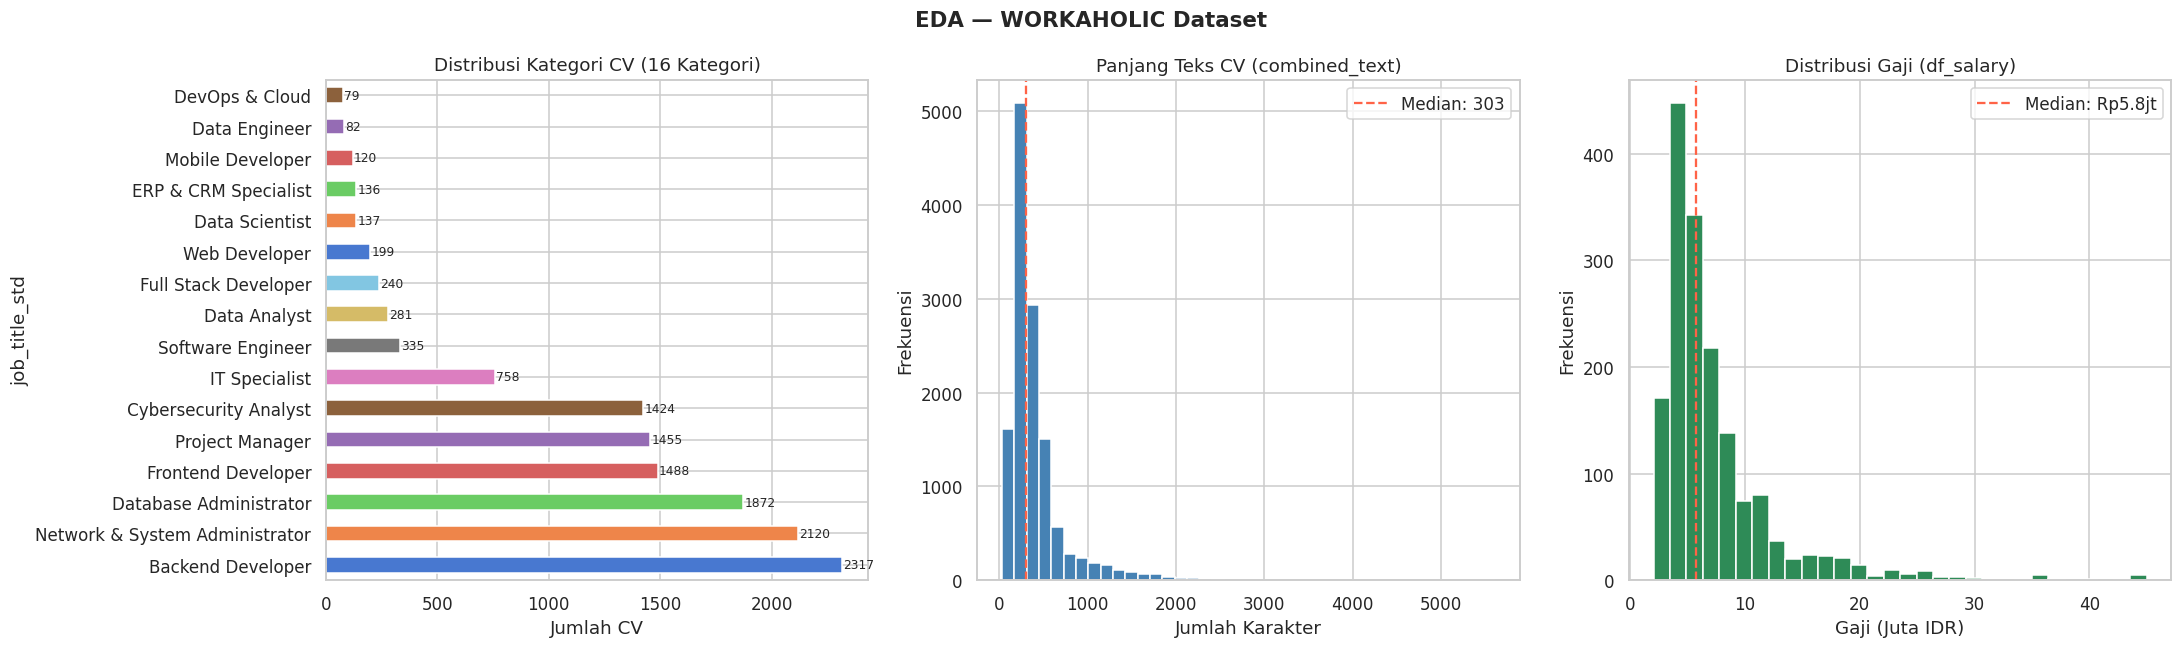

Ringkasan:
  CV         : 13,043 entri | 16 kategori
  Lowongan   : 241,820 entri
  Gaji       : 1,660 entri | median Rp5.8jt
  Teks CV    : avg 404 char | min 30 | max 5611


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('EDA — WORKAHOLIC Dataset', fontsize=14, fontweight='bold')

# 1. Distribusi kategori CV
cat_counts = df_cv['job_title_std'].value_counts()
cat_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('muted'))
axes[0].set_title('Distribusi Kategori CV (16 Kategori)')
axes[0].set_xlabel('Jumlah CV')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8)

# 2. Distribusi panjang teks combined
text_lens = df_cv['combined_text'].str.len()
axes[1].hist(text_lens, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Panjang Teks CV (combined_text)')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(text_lens.median(), color='tomato', linestyle='--',
                label=f'Median: {text_lens.median():.0f}')
axes[1].legend()

# 3. Distribusi gaji
df_sal['salary_mid'] = pd.to_numeric(df_sal['salary_mid'], errors='coerce')
sal_clean = df_sal['salary_mid'].dropna()
axes[2].hist(sal_clean / 1e6, bins=30, color='seagreen', edgecolor='white')
axes[2].set_title('Distribusi Gaji (df_salary)')
axes[2].set_xlabel('Gaji (Juta IDR)')
axes[2].set_ylabel('Frekuensi')
axes[2].axvline(sal_clean.median() / 1e6, color='tomato', linestyle='--',
                label=f'Median: Rp{sal_clean.median()/1e6:.1f}jt')
axes[2].legend()

plt.tight_layout()
plt.savefig('models/eda_plot.png', bbox_inches='tight')
plt.show()

print('Ringkasan:')
print(f'  CV         : {len(df_cv):,} entri | {df_cv["job_title_std"].nunique()} kategori')
print(f'  Lowongan   : {len(df_loker):,} entri')
print(f'  Gaji       : {len(df_sal):,} entri | median Rp{sal_clean.median()/1e6:.1f}jt')
print(f'  Teks CV    : avg {text_lens.mean():.0f} char | min {text_lens.min()} | max {text_lens.max()}')

## 4. Preprocessing & Tokenisasi

Pipeline:
1. `clean_text()` — lowercase, hapus non-alfanumerik, hapus stopwords
2. `Tokenizer` Keras — build vocab dari combined_text CV
3. `pad_sequences` — semua sequence ke panjang `MAX_LEN`
4. `LabelEncoder` — encode 16 kategori ke integer

In [5]:
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Konfigurasi ──
MAX_VOCAB    = 20_000
MAX_LEN      = 128     # panjang sequence (cukup untuk skills+title)
RANDOM_STATE = 42

# Stopwords Indonesia + Inggris
ID_STOPWORDS = {
    'dan','atau','yang','di','ke','dari','ini','itu','juga','dengan','untuk',
    'pada','adalah','sebagai','dalam','tidak','akan','sudah','telah','saya',
    'kami','kita','ada','bisa','dapat','lebih','seperti','serta','bahwa',
    'namun','jika','the','and','or','is','are','was','were','be','been',
    'have','has','do','does','did','will','would','could','should','may',
    'might','shall','can','to','of','in','for','on','with','at','by',
    'from','as','an','a',
}

def clean_text(text: str) -> str:
    """Lowercase, hapus karakter non-alfanumerik, hapus stopwords."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = [t for t in text.split() if t not in ID_STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

# ── Bersihkan teks ──
df_cv['clean_text']       = df_cv['combined_text'].apply(clean_text)
df_loker['clean_fulltext']= df_loker['full_text'].fillna('').apply(clean_text)

# Hapus baris dengan teks terlalu pendek
df_cv = df_cv[df_cv['clean_text'].str.len() > 10].reset_index(drop=True)
print(f'CV setelah filter: {len(df_cv):,} baris')

# ── Tokenisasi ──
X_text = df_cv['clean_text'].values
y_text = df_cv['job_title_std'].values

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_text)

X_seq    = tokenizer.texts_to_sequences(X_text)
X_padded = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Juga tokenisasi loker (untuk embedding cosine similarity)
X_loker_seq    = tokenizer.texts_to_sequences(df_loker['clean_fulltext'].values)
X_loker_padded = pad_sequences(X_loker_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# ── Label Encoding ──
label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(y_text)
NUM_CLASSES   = len(label_encoder.classes_)

# ── Train / Val Split ──
X_train, X_val, y_train, y_val = train_test_split(
    X_padded, y_encoded,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f'\nPreprocessing selesai:')
print(f'  Vocab size   : {len(tokenizer.word_index):,} (max {MAX_VOCAB})')
print(f'  MAX_LEN      : {MAX_LEN}')
print(f'  X_train      : {X_train.shape}')
print(f'  X_val        : {X_val.shape}')
print(f'  Num classes  : {NUM_CLASSES}')
print(f'  Kategori     : {list(label_encoder.classes_)}')

CV setelah filter: 13,043 baris

Preprocessing selesai:
  Vocab size   : 18,480 (max 20000)
  MAX_LEN      : 128
  X_train      : (10434, 128)
  X_val        : (2609, 128)
  Num classes  : 16
  Kategori     : ['Backend Developer', 'Cybersecurity Analyst', 'Data Analyst', 'Data Engineer', 'Data Scientist', 'Database Administrator', 'DevOps & Cloud', 'ERP & CRM Specialist', 'Frontend Developer', 'Full Stack Developer', 'IT Specialist', 'Mobile Developer', 'Network & System Administrator', 'Project Manager', 'Software Engineer', 'Web Developer']


## 5. Build Model — Embedding + BiLSTM

```
Input (128 tokens)
    ↓
Embedding (vocab=20k, dim=128)
    ↓
BiLSTM (64 units, return_sequences=True)
    ↓  Dropout 30%
BiLSTM (32 units) ← output dipakai sebagai CV embedding
    ↓  Dropout 30%
Dense (64, ReLU)
    ↓  Dropout 30%
Output Softmax (16 kelas)
```

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dropout, Dense, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print(f'TensorFlow: {tf.__version__}')

# ── Hyperparameter ──
EMBEDDING_DIM = 128
LSTM_UNITS_1  = 64
LSTM_UNITS_2  = 32
DROPOUT       = 0.3
LR            = 0.001

# ── Arsitektur ──
inp = Input(shape=(MAX_LEN,), dtype='int32', name='input')

x = Embedding(MAX_VOCAB, EMBEDDING_DIM, input_length=MAX_LEN, name='embedding')(inp)

x = Bidirectional(
    LSTM(LSTM_UNITS_1, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
    name='bilstm_1'
)(x)
x = Dropout(DROPOUT)(x)

# Layer ini juga dipakai sebagai encoder untuk cosine similarity
embed_out = Bidirectional(
    LSTM(LSTM_UNITS_2, return_sequences=False, dropout=0.1, recurrent_dropout=0.1),
    name='bilstm_2'
)(x)
x = Dropout(DROPOUT)(embed_out)

x = Dense(64, activation='relu', name='dense_1')(x)
x = Dropout(DROPOUT)(x)

out = Dense(NUM_CLASSES, activation='softmax', name='output')(x)

model = Model(inputs=inp, outputs=out, name='workaholic_bilstm')
model.compile(
    optimizer=Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Sub-model encoder — untuk ambil embedding CV/lowongan
embed_model = Model(inputs=inp, outputs=embed_out, name='workaholic_encoder')

model.summary()
print(f'\nTotal parameter: {model.count_params():,}')

TensorFlow: 2.20.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "workaholic_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 128, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,705,232 (10.32 MB)

 Trainable params: 2,705,232 (10.32 MB)

 Non-trainable params: 0 (0.00 B)


Total parameter: 2,705,232


## 6. Training

In [7]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Class weights — handle imbalanced data
cw_vals      = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: w for i, w in enumerate(cw_vals)}

callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=4,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-5, verbose=1
    ),
    ModelCheckpoint(
        'models/best_bilstm.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

print(f'Training: {len(X_train):,} | Validasi: {len(X_val):,} | Kelas: {NUM_CLASSES}')
print('Mulai training...\n')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss,   val_acc   = model.evaluate(X_val,   y_val,   verbose=0)
print(f'\nTrain accuracy : {train_acc:.4f}')
print(f'Val accuracy   : {val_acc:.4f}')

Training: 10,434 | Validasi: 2,609 | Kelas: 16
Mulai training...

Epoch 1/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2223 - loss: 2.5328
Epoch 1: val_accuracy improved from None to 0.74780, saving model to models/best_bilstm.keras

Epoch 1: finished saving model to models/best_bilstm.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.3655 - loss: 2.1487 - val_accuracy: 0.7478 - val_loss: 1.0276 - learning_rate: 0.0010
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6745 - loss: 1.1608
Epoch 2: val_accuracy improved from 0.74780 to 0.87811, saving model to models/best_bilstm.keras

Epoch 2: finished saving model to models/best_bilstm.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.7175 - loss: 1.0259 - val_accuracy: 0.8781 - val_loss: 0.5057 - learning_rate: 0.0010
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8312 - loss: 0.6802
Epoch 3: val_accuracy improved from 0.87811 to 0.89345, saving model to models/best_

     CEK DISTRIBUSI DATA & BOBOT PENYEIMBANG (CLASS WEIGHTS)
 Kelas/Kategori ID  Jumlah Data Asli  Bobot (Class Weight)
                 0              1853                0.3519
                12              1696                0.3845
                 5              1498                0.4353
                 8              1190                0.5480
                13              1164                0.5602
                 1              1139                0.5725
                10               606                1.0761
                14               268                2.4333
                 2               225                2.8983
                 9               192                3.3965
                15               159                4.1014
                 4               110                5.9284
                 7               109                5.9828
                11                96                6.7930
                 3                66                9.

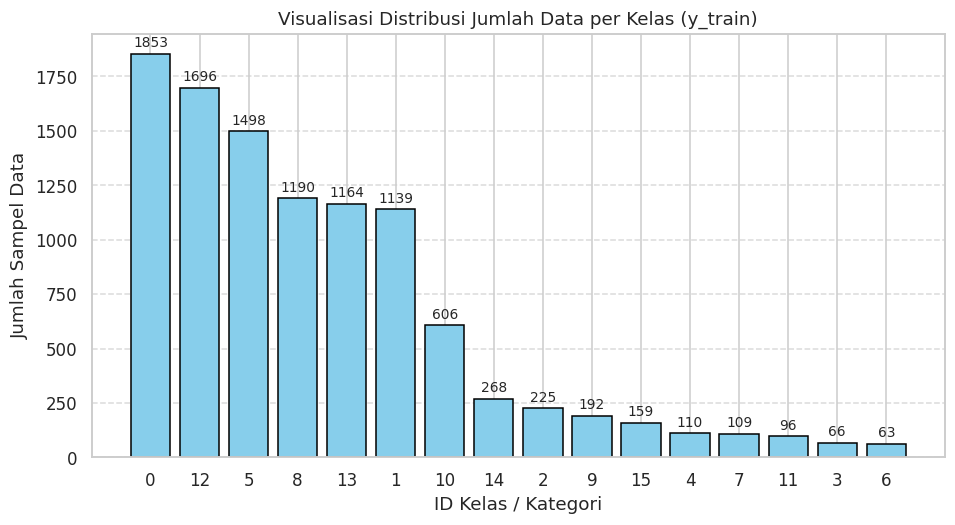

In [23]:
import collections
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Hitung distribusi asli dari y_train
data_counts = collections.Counter(y_train)

# 2. Buat DataFrame untuk membandingkan Jumlah Data vs Bobot Model
check_balance_df = pd.DataFrame({
    'Kelas/Kategori ID': list(data_counts.keys()),
    'Jumlah Data Asli': list(data_counts.values()),
    'Bobot (Class Weight)': [round(class_weights[i], 4) for i in data_counts.keys()]
}).sort_values(by='Jumlah Data Asli', ascending=False).reset_index(drop=True)

print("=" * 65)
print("     CEK DISTRIBUSI DATA & BOBOT PENYEIMBANG (CLASS WEIGHTS)")
print("=" * 65)
print(check_balance_df.to_string(index=False))
print("-" * 65)

# 3. Analisis Kesimpulan Otomatis
max_data = check_balance_df['Jumlah Data Asli'].max()
min_data = check_balance_df['Jumlah Data Asli'].min()
rasio = max_data / min_data

print(f"Rasio ketimpangan data asli (Terbanyak : Tergokil): {rasio:.2f} : 1")
if rasio > 3:
    print("📢 STATUS: Data asli kamu SANGAT TIMPANG (Imbalanced).")
    print("✅ Solusi 'class_weight' di kode sebelumnya SUDAH BENAR & AKTIF.")
    print("   (Bisa dilihat: Kelas dengan data sedikit otomatis mendapat Bobot yang jauh lebih besar).")
else:
    print("📢 STATUS: Data asli kamu relatif seimbang.")
    print("   (Nilai Bobot di setiap kelas akan seragam mendekati angka 1.0).")

# 4. Gambar Grafik Batang untuk Visualisasi (Opsional tapi membantu)
plt.figure(figsize=(10, 5))
bars = plt.bar(check_balance_df['Kelas/Kategori ID'].astype(str), check_balance_df['Jumlah Data Asli'], color='skyblue', edgecolor='black')
plt.title('Visualisasi Distribusi Jumlah Data per Kelas (y_train)')
plt.xlabel('ID Kelas / Kategori')
plt.ylabel('Jumlah Sampel Data')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan angka di atas grafik batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max_data*0.01), f'{int(yval)}', ha='center', va='bottom', fontsize=9)

plt.show()

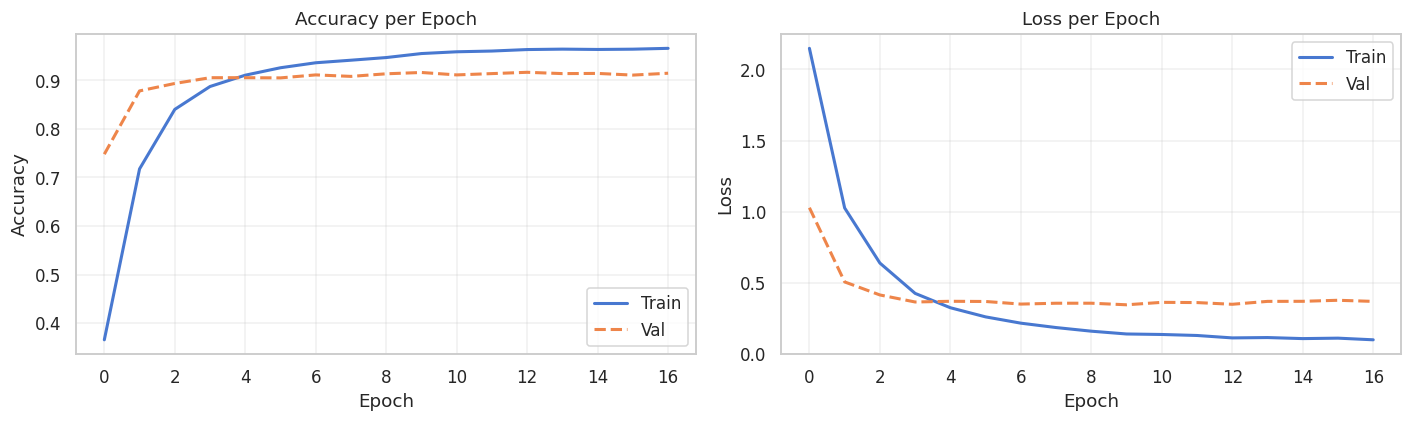

In [8]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
ax1.set_title('Accuracy per Epoch'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
ax2.set_title('Loss per Epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/training_curves.png', bbox_inches='tight')
plt.show()

## 7. Evaluasi Model

Validation Accuracy: 0.9164

                                precision    recall  f1-score   support

             Backend Developer     0.9657    0.8491    0.9037       464
         Cybersecurity Analyst     0.9555    0.9789    0.9671       285
                  Data Analyst     0.8167    0.8750    0.8448        56
                 Data Engineer     0.8824    0.9375    0.9091        16
                Data Scientist     0.8621    0.9259    0.8929        27
        Database Administrator     0.9835    0.9572    0.9702       374
                DevOps & Cloud     0.6667    0.7500    0.7059        16
          ERP & CRM Specialist     0.8462    0.8148    0.8302        27
            Frontend Developer     0.9461    0.9430    0.9445       298
          Full Stack Developer     0.6667    0.9583    0.7863        48
                 IT Specialist     0.8176    0.8553    0.8360       152
              Mobile Developer     0.9500    0.7917    0.8636        24
Network & System Administrator    

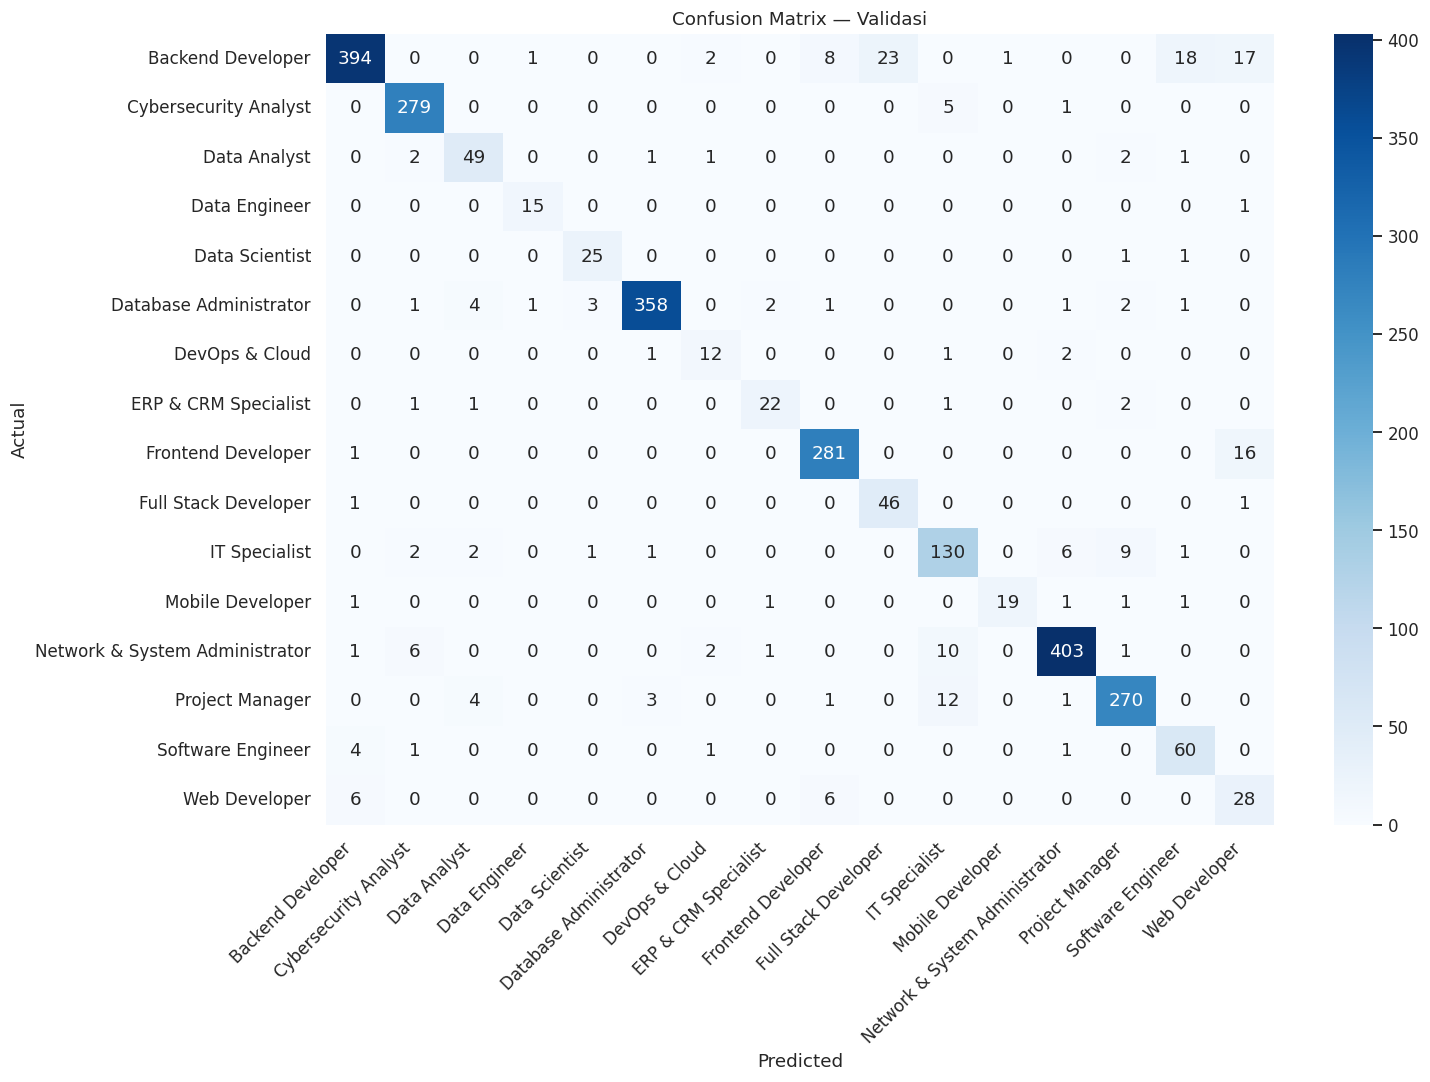

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_probs  = model.predict(X_val, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print(f'Validation Accuracy: {accuracy_score(y_val, y_pred_labels):.4f}')
print()
print(classification_report(
    y_val, y_pred_labels,
    target_names=label_encoder.classes_,
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_labels)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix — Validasi')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('models/confusion_matrix.png', bbox_inches='tight')
plt.show()

## 8. Inference — Prediksi + Rekomendasi Lowongan

Pipeline:
1. Teks CV → tokenisasi → padding → forward pass → prediksi kategori
2. Teks CV → BiLSTM encoder → embedding CV
3. Cosine similarity embedding CV vs embedding semua lowongan → top-K

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

# Pre-compute embedding semua lowongan (sekali, di-cache)
print(f'Menghitung embedding {len(df_loker):,} lowongan (ini bisa 5-15 menit)...')
print('Tips: gunakan GPU di Colab (Runtime → Change runtime type → T4 GPU)')

job_embeddings = embed_model.predict(X_loker_padded, batch_size=256, verbose=1)
print(f'\nJob embeddings shape: {job_embeddings.shape}')
print('Pre-compute selesai!')

Menghitung embedding 241,820 lowongan (ini bisa 5-15 menit)...
Tips: gunakan GPU di Colab (Runtime → Change runtime type → T4 GPU)
945/945 ━━━━━━━━━━━━━━━━━━━━ 298s 313ms/step

Job embeddings shape: (241820, 64)
Pre-compute selesai!


In [11]:
# ── Fungsi Inference ──────────────────────────────────────────────────────────

SKILL_KEYWORDS = [
    'python','java','javascript','typescript','react','vue','angular','nodejs',
    'django','flask','fastapi','spring','springboot','golang','rust','kotlin',
    'swift','flutter','dart','sql','mysql','postgresql','mongodb','redis',
    'elasticsearch','kafka','rabbitmq','docker','kubernetes','terraform',
    'ansible','jenkins','github','gitlab','cicd','aws','gcp','azure','linux',
    'bash','nginx','apache','tensorflow','pytorch','keras','scikit-learn',
    'pandas','numpy','matplotlib','spark','hadoop','airflow','dbt','tableau',
    'powerbi','looker','excel','figma','html','css','tailwind','bootstrap',
    'rest','graphql','grpc','microservices','agile','scrum',
    'penetration testing','vulnerability','firewall','siem','kali linux',
    'sap','oracle','erp','crm','network','cisco','ccna','vmware',
]


def predict_category(cv_text: str):
    """
    Prediksi kategori pekerjaan dari teks CV menggunakan BiLSTM.
    Returns: (category, confidence_pct, top3_categories)
    """
    cleaned = clean_text(cv_text)
    if not cleaned:
        return 'Unknown', 0.0, []

    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs  = model.predict(padded, verbose=0)[0]

    idx      = int(np.argmax(probs))
    category = label_encoder.classes_[idx]
    conf     = float(probs[idx]) * 100

    top3_idx = np.argsort(probs)[::-1][:3]
    top3 = [
        {'category': label_encoder.classes_[i], 'confidence_pct': round(float(probs[i]) * 100, 2)}
        for i in top3_idx
    ]
    return category, round(conf, 2), top3


def detect_skills(text: str) -> list:
    """Deteksi skill dari teks CV."""
    text_lower = text.lower()
    return [kw for kw in SKILL_KEYWORDS if kw in text_lower]


def recommend_jobs(cv_text: str, top_k: int = 10) -> list:
    """
    Rekomendasikan top-K lowongan berdasarkan cosine similarity
    antara BiLSTM embedding CV dan embedding deskripsi lowongan.
    """
    cleaned  = clean_text(cv_text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    cv_embed = embed_model.predict(padded, verbose=0)
    sims     = cosine_similarity(cv_embed, job_embeddings)[0]
    top_idx  = np.argsort(sims)[::-1][:top_k]

    results = []
    for rank, i in enumerate(top_idx, 1):
        row     = df_loker.iloc[i]
        sal_min = row.get('salaryMin')
        sal_max = row.get('salaryMax')
        if pd.notna(sal_min) and pd.notna(sal_max) and float(sal_max) > 0:
            salary_range = f'Rp {int(sal_min):,} - Rp {int(sal_max):,}'
        else:
            salary_range = 'Tidak tersedia'
        results.append({
            'rank'          : rank,
            'jobTitle'      : str(row.get('jobTitle', 'Unknown')),
            'companyName'   : str(row.get('companyName', 'Unknown')),
            'locations'     : str(row.get('locations', '-')),
            'employment'    : str(row.get('employment', '-')),
            'categoriesName': str(row.get('categoriesName', '-')),
            'similarity_pct': round(float(sims[i]) * 100, 2),
            'salary_range'  : salary_range,
        })
    return results


print('Fungsi inference siap.')

Fungsi inference siap.


In [12]:
# Quick inference test
SAMPLE_CVs = {
    'Data Scientist'    : 'python tensorflow keras machine learning deep learning nlp pytorch data analysis pandas sql statistics',
    'Backend Developer' : 'java spring boot rest api microservices docker kubernetes postgresql redis kafka maven',
    'Frontend Developer': 'javascript react typescript html css tailwind redux figma nextjs webpack vue',
    'Cybersecurity Analyst': 'network security penetration testing firewall siem soc vulnerability assessment kali linux',
    'DevOps & Cloud'    : 'aws gcp azure docker kubernetes ci cd jenkins terraform ansible linux bash',
}

print('=' * 65)
print('  QUICK INFERENCE TEST')
print('=' * 65)
for expected, cv_text in SAMPLE_CVs.items():
    cat, conf, _ = predict_category(cv_text)
    match = 'v' if cat == expected else 'x'
    print(f'[{match}] Expected: {expected:<30} Prediksi: {cat} ({conf:.1f}%)')

print()
print('Top 5 Rekomendasi untuk Data Scientist CV:')
recs = recommend_jobs(SAMPLE_CVs['Data Scientist'], top_k=5)
for r in recs:
    print(f"  {r['rank']}. {r['jobTitle'][:40]:<40} @ {r['companyName'][:20]:<20}  sim: {r['similarity_pct']}%")

  QUICK INFERENCE TEST
[v] Expected: Data Scientist                 Prediksi: Data Scientist (99.9%)
[v] Expected: Backend Developer              Prediksi: Backend Developer (98.3%)
[x] Expected: Frontend Developer             Prediksi: Web Developer (85.4%)
[x] Expected: Cybersecurity Analyst          Prediksi: Network & System Administrator (99.9%)
[x] Expected: DevOps & Cloud                 Prediksi: IT Specialist (96.6%)

Top 5 Rekomendasi untuk Data Scientist CV:
  1. Tax Senior Specialist                    @ JD .ID (PT Ritel Ber  sim: 98.24%
  2. Tax Specialist                           @ JD .ID (PT Ritel Ber  sim: 98.24%
  3. Mobile Developer                         @ PT Asuransi MSIG Ind  sim: 98.2%
  4. Live Streaming Operation Manager         @ KUAISHOU              sim: 98.15%
  5. IT Operation (Office AUtomation)         @ PT. HTC Global Softw  sim: 98.01%


## 9. Estimasi Gaji

**Tidak butuh model terpisah.**  
Cukup hitung statistik (P25, Median, P75) dari `df_salary.csv`  
berdasarkan kategori yang diprediksi BiLSTM.

In [13]:
# Mapping kategori → keyword pencarian di df_salary
CATEGORY_SALARY_KEYWORDS = {
    'Data Scientist'                : ['data scientist','machine learning','ml engineer'],
    'Data Analyst'                  : ['data analyst','business analyst','analyst'],
    'Data Engineer'                 : ['data engineer','etl','big data'],
    'Backend Developer'             : ['backend','back-end','java developer','python developer','net developer'],
    'Frontend Developer'            : ['frontend','front-end','react developer','vue developer'],
    'Full Stack Developer'          : ['full stack','fullstack'],
    'Software Engineer'             : ['software engineer','software developer','programmer'],
    'Mobile Developer'              : ['mobile','android','ios','flutter developer'],
    'Web Developer'                 : ['web developer','web programmer'],
    'DevOps & Cloud'                : ['devops','cloud engineer','site reliability','sre'],
    'Database Administrator'        : ['database','dba','sql developer'],
    'Network & System Administrator': ['network','system administrator','sysadmin','it infrastructure'],
    'Cybersecurity Analyst'         : ['security','cybersecurity','it security','soc analyst'],
    'IT Specialist'                 : ['it support','it specialist','technical support','helpdesk'],
    'Project Manager'               : ['project manager','it project','product manager','scrum master'],
    'ERP & CRM Specialist'          : ['erp','crm','sap','oracle consultant'],
}


def estimate_salary(category: str) -> dict:
    """
    Estimasi kisaran gaji berdasarkan kategori.

    Metode: filter df_salary berdasarkan keyword kategori,
    lalu hitung P25, Median, P75. Fallback ke seluruh data
    jika tidak ada data untuk kategori tersebut.
    """
    keywords = CATEGORY_SALARY_KEYWORDS.get(category, [category.lower()])

    mask = df_sal['jobTitle'].str.lower().apply(
        lambda t: any(kw in str(t) for kw in keywords)
    )
    subset = df_sal[mask]['salary_mid'].dropna()

    if subset.empty:
        subset  = df_sal['salary_mid'].dropna()
        note    = 'Estimasi berdasarkan data gaji keseluruhan'
        matched = False
    else:
        note    = f'Berdasarkan {len(subset):,} data kategori "{category}"'
        matched = True

    p25    = int(subset.quantile(0.25))
    median = int(subset.median())
    p75    = int(subset.quantile(0.75))

    return {
        'available'        : True,
        'category_matched' : matched,
        'salary_p25'       : p25,
        'salary_median'    : median,
        'salary_p75'       : p75,
        'salary_range'     : f'Rp {p25:,} - Rp {p75:,} / bulan',
        'salary_median_fmt': f'Rp {median:,} / bulan',
        'sample_count'     : int(len(subset)),
        'note'             : note,
    }


# Test semua kategori
print('Estimasi Gaji per Kategori:')
print('=' * 70)
for cat in label_encoder.classes_:
    sal = estimate_salary(cat)
    matched_str = 'v' if sal['category_matched'] else 'x(fallback)'
    print(f'  [{matched_str}] {cat:<35} {sal["salary_range"]}')

print()
print('Fungsi estimate_salary() siap.')

Estimasi Gaji per Kategori:
  [v] Backend Developer                   Rp 6,312,500 - Rp 14,375,000 / bulan
  [v] Cybersecurity Analyst               Rp 8,875,000 - Rp 15,175,000 / bulan
  [v] Data Analyst                        Rp 5,375,000 - Rp 12,000,000 / bulan
  [v] Data Engineer                       Rp 11,250,000 - Rp 15,200,000 / bulan
  [v] Data Scientist                      Rp 22,500,000 - Rp 22,500,000 / bulan
  [v] Database Administrator              Rp 7,425,000 - Rp 18,900,000 / bulan
  [v] DevOps & Cloud                      Rp 9,050,000 - Rp 25,312,500 / bulan
  [v] ERP & CRM Specialist                Rp 5,500,000 - Rp 8,500,000 / bulan
  [v] Frontend Developer                  Rp 8,500,000 - Rp 14,500,000 / bulan
  [v] Full Stack Developer                Rp 7,250,000 - Rp 15,125,000 / bulan
  [v] IT Specialist                       Rp 4,725,000 - Rp 8,500,000 / bulan
  [v] Mobile Developer                    Rp 6,625,000 - Rp 11,250,000 / bulan
  [v] Network & System A

In [14]:
def analyze_cv(cv_text: str, top_k: int = 10) -> dict:
    """
    Pipeline lengkap analisis CV:
    1. Prediksi kategori (BiLSTM)
    2. Deteksi skill
    3. Rekomendasi lowongan (cosine similarity BiLSTM embedding)
    4. Estimasi gaji (statistik df_salary)
    """
    category, confidence, top3 = predict_category(cv_text)
    skills  = detect_skills(cv_text)
    jobs    = recommend_jobs(cv_text, top_k=top_k)
    salary  = estimate_salary(category)

    return {
        'predicted_category': category,
        'confidence_pct'    : confidence,
        'top3_categories'   : top3,
        'skills_detected'   : skills,
        'skill_count'       : len(skills),
        'recommendations'   : jobs,
        'salary_estimate'   : salary,
    }


# Demo lengkap
TEST_CV = """
Experienced Backend Developer with 3 years building scalable REST APIs.
Proficient in Python, Java, Spring Boot, Docker, Kubernetes, and PostgreSQL.
Strong experience with microservices architecture, Redis caching, and Kafka.
Familiar with CI/CD pipelines using Jenkins and GitHub Actions. Git, Linux.
"""

result = analyze_cv(TEST_CV, top_k=5)

print('=' * 60)
print('  HASIL ANALISIS CV')
print('=' * 60)
print(f"  Kategori     : {result['predicted_category']} ({result['confidence_pct']:.1f}%)")
print(f"  Top 3        : {[c['category'] for c in result['top3_categories']]}")
print(f"  Skills       : {result['skill_count']} — {', '.join(result['skills_detected'][:8])}")
print()
print(f"  Estimasi Gaji: {result['salary_estimate']['salary_range']}")
print(f"  Median Gaji  : {result['salary_estimate']['salary_median_fmt']}")
print(f"  ({result['salary_estimate']['note']})")
print()
print('  TOP 5 REKOMENDASI LOWONGAN:')
print('  ' + '-' * 55)
for r in result['recommendations']:
    print(f"  {r['rank']}. {r['jobTitle'][:40]:<40}")
    print(f"     {r['companyName'][:30]:<30}  [{r['locations']}]")
    print(f"     Similarity: {r['similarity_pct']}%  |  Gaji: {r['salary_range']}")
    print()

  HASIL ANALISIS CV
  Kategori     : Backend Developer (99.5%)
  Top 3        : ['Backend Developer', 'Web Developer', 'Software Engineer']
  Skills       : 14 — python, java, spring, sql, postgresql, redis, kafka, docker

  Estimasi Gaji: Rp 6,312,500 - Rp 14,375,000 / bulan
  Median Gaji  : Rp 10,500,000 / bulan
  (Berdasarkan 42 data kategori "Backend Developer")

  TOP 5 REKOMENDASI LOWONGAN:
  -------------------------------------------------------
  1. .NET Developer                          
     PT Alpha Salmon                 [Jakarta Raya]
     Similarity: 99.27%  |  Gaji: Tidak tersedia

  2. Backend Java Developer                  
     PT Nityo Infotech               [Jakarta Raya]
     Similarity: 99.24%  |  Gaji: Rp 10,000,000 - Rp 15,000,000

  3. Java Developer                          
     PT Esha Parama Teknologi        [Jakarta Raya]
     Similarity: 99.17%  |  Gaji: Tidak tersedia

  4. BackEnd Java Developer                  
     PT CITTA PARAMA GUNA            

## 9b. Input CV dari PDF

Upload file PDF CV kamu, lalu jalankan cell di bawah.

In [15]:
def extract_text_pdf(pdf_path: str) -> str:
    """Ekstrak teks dari PDF. Prioritas pdfplumber, fallback pypdf."""
    # Coba pdfplumber dulu
    try:
        import pdfplumber
        pages = []
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                t = page.extract_text()
                if t:
                    pages.append(t)
        text = ' '.join(pages).strip()
        if text:
            return text
    except Exception as e:
        print(f'pdfplumber gagal: {e} — mencoba pypdf...')

    # Fallback: pypdf
    from pypdf import PdfReader
    reader = PdfReader(pdf_path)
    return ' '.join(p.extract_text() or '' for p in reader.pages).strip()


def analyze_cv_from_pdf(pdf_path: str, top_k: int = 10) -> dict:
    """Analisis CV dari file PDF."""
    cv_text = extract_text_pdf(pdf_path)
    if not cv_text or len(cv_text.strip()) < 20:
        return {'error': 'Teks terlalu pendek atau kosong. Pastikan PDF bukan scan gambar.'}
    result = analyze_cv(cv_text, top_k=top_k)
    result['text_length']  = len(cv_text)
    result['text_preview'] = cv_text[:300]
    return result


# ── Contoh pakai PDF ──────────────────────────────────────────────────────────
# Ganti path di bawah dengan CV kamu
PDF_PATH = 'dataset/your_cv.pdf'

if Path(PDF_PATH).exists():
    result_pdf = analyze_cv_from_pdf(PDF_PATH, top_k=5)
    if 'error' in result_pdf:
        print(f'Error: {result_pdf["error"]}')
    else:
        print('=' * 60)
        print('  ANALISIS CV DARI PDF')
        print('=' * 60)
        print(f"  Teks diekstrak : {result_pdf['text_length']} karakter")
        print(f"  Preview        : {result_pdf['text_preview'][:150]}...")
        print(f"  Kategori       : {result_pdf['predicted_category']} ({result_pdf['confidence_pct']:.1f}%)")
        print(f"  Skills         : {result_pdf['skill_count']} — {', '.join(result_pdf['skills_detected'][:8])}")
        print(f"  Estimasi Gaji  : {result_pdf['salary_estimate']['salary_range']}")
        print()
        print('  TOP 5 REKOMENDASI:')
        for r in result_pdf['recommendations'][:5]:
            print(f"  {r['rank']}. {r['jobTitle'][:45]:<45}  sim: {r['similarity_pct']}%")
else:
    print(f"File '{PDF_PATH}' tidak ditemukan.")
    print("Letakkan CV PDF di dataset/ atau ubah PDF_PATH.")

File 'dataset/your_cv.pdf' tidak ditemukan.
Letakkan CV PDF di dataset/ atau ubah PDF_PATH.


In [16]:
import os
from pathlib import Path
from google.colab import files

print("=" * 60)
print("             UNGGAH CV KAMU (FORMAT .PDF)")
print("=" * 60)

# 1. Munculkan tombol upload file di Google Colab
uploaded = files.upload()

# 2. Proses file yang berhasil diunggah
if uploaded:
    # Mengambil nama file pertama yang diunggah
    uploaded_file_name = list(uploaded.keys())[0]

    # Validasi apakah file berupa PDF
    if not uploaded_file_name.lower().endswith('.pdf'):
        print("\n❌ Error: File yang kamu unggah bukan PDF. Silakan coba lagi.")
    else:
        print(f"\n✅ Berhasil mengunggah: {uploaded_file_name}")

        # Definisikan path file sementara di Colab
        PDF_PATH = uploaded_file_name

        # 3. Jalankan fungsi analisis jika file ada
        if Path(PDF_PATH).exists():
            print("\nMemproses ekstraksi teks dan analisis dengan model WORKAHOLIC...")
            print("-" * 60)

            # Memanggil fungsi analisis dari kode kamu sebelumnya
            result_pdf = analyze_cv_from_pdf(PDF_PATH, top_k=5)

            # 4. Tampilkan Hasil Analisis ke Layar
            if 'error' in result_pdf:
                print(f'❌ Error: {result_pdf["error"]}')
            else:
                print('=' * 60)
                print('                HASIL ANALISIS CV')
                print('=' * 60)
                print(f" 🔹 Teks diekstrak : {result_pdf['text_length']} karakter")
                print(f" 🔹 Preview        : {result_pdf['text_preview'][:120]}...")
                print(f" 🔹 Kategori       : {result_pdf['predicted_category']} ({result_pdf['confidence_pct']:.1f}%)")
                print(f" 🔹 Skills         : {result_pdf['skill_count']} — {', '.join(result_pdf['skills_detected'][:8])}")
                print(f" 🔹 Estimasi Gaji  : {result_pdf['salary_estimate']['salary_range']}")
                print()
                print(' 🚀 TOP 5 REKOMENDASI LOWONGAN KERJA:')
                print('-' * 60)
                for r in result_pdf['recommendations'][:5]:
                    print(f"  [{r['rank']}] {r['jobTitle'][:45]:<45} | Sim: {r['similarity_pct']}%")
                print('=' * 60)

        else:
            print(f"\n❌ Error: File '{PDF_PATH}' gagal dibaca oleh sistem.")
else:
    print("\n⚠️ Proses unggah dibatalkan oleh pengguna.")

             UNGGAH CV KAMU (FORMAT .PDF)


Saving AbigailHallResume.pdf to AbigailHallResume (1).pdf

✅ Berhasil mengunggah: AbigailHallResume (1).pdf

Memproses ekstraksi teks dan analisis dengan model WORKAHOLIC...
------------------------------------------------------------
                HASIL ANALISIS CV
 🔹 Teks diekstrak : 2915 karakter
 🔹 Preview        : ABIGAIL HALL
Software Engineer | Python | Java | Collaborative Coder
​ 1- 234 -555-1234 ​Email ​linkedin.com ​San Antoni...
 🔹 Kategori       : Software Engineer (99.6%)
 🔹 Skills         : 11 — python, java, javascript, github, aws, spark, excel, html
 🔹 Estimasi Gaji  : Rp 5,958,093 - Rp 10,625,000 / bulan

 🚀 TOP 5 REKOMENDASI LOWONGAN KERJA:
------------------------------------------------------------
  [1] HR Staff                                      | Sim: 98.39%
  [2] HR Operation Staff                            | Sim: 98.39%
  [3] Graphic Designer                              | Sim: 98.37%
  [4] Content Creator                               | Sim: 98.08%
  [5

## 10. Save Artifacts

In [17]:
import pickle, json

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

# 1. Model utama BiLSTM
model.save(str(MODELS_DIR / 'workaholic_bilstm.keras'))
print('v  Model BiLSTM    → models/workaholic_bilstm.keras')

# 2. Encoder model (sub-model untuk embedding)
embed_model.save(str(MODELS_DIR / 'workaholic_encoder.keras'))
print('v  Encoder model   → models/workaholic_encoder.keras')

# 3. Tokenizer
with open(MODELS_DIR / 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('v  Tokenizer       → models/tokenizer.pkl')

# 4. Label encoder
with open(MODELS_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print('v  Label encoder   → models/label_encoder.pkl')

# 5. Job embeddings (pre-computed)
np.save(str(MODELS_DIR / 'job_embeddings.npy'), job_embeddings)
print('v  Job embeddings  → models/job_embeddings.npy')

# 6. Jobs metadata (title, company, dll untuk API response)
jobs_meta = df_loker[['jobTitle','companyName','locations','employment','categoriesName','salaryMin','salaryMax']].copy()
jobs_meta = jobs_meta.fillna('').astype(str)
jobs_meta.to_json(str(MODELS_DIR / 'jobs_meta.json'), orient='records', force_ascii=False)
print('v  Jobs metadata   → models/jobs_meta.json')

# 7. Metadata model
metadata = {
    'model_name'    : 'workaholic_bilstm',
    'architecture'  : 'Embedding + 2x BiLSTM + Dense',
    'max_vocab'     : MAX_VOCAB,
    'max_len'       : MAX_LEN,
    'embedding_dim' : EMBEDDING_DIM,
    'lstm_units'    : [LSTM_UNITS_1, LSTM_UNITS_2],
    'num_classes'   : NUM_CLASSES,
    'categories'    : list(label_encoder.classes_),
    'train_accuracy': float(train_acc),
    'val_accuracy'  : float(val_acc),
    'total_params'  : int(model.count_params()),
    'salary_method' : 'Statistical P25/Median/P75 from df_salary.csv',
}
with open(MODELS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('v  Metadata        → models/metadata.json')

print(f'\nSemua artifacts tersimpan di folder models/')
print(f'  Ukuran job_embeddings: {job_embeddings.nbytes / 1e6:.1f} MB')

v  Model BiLSTM    → models/workaholic_bilstm.keras
v  Encoder model   → models/workaholic_encoder.keras
v  Tokenizer       → models/tokenizer.pkl
v  Label encoder   → models/label_encoder.pkl
v  Job embeddings  → models/job_embeddings.npy
v  Jobs metadata   → models/jobs_meta.json
v  Metadata        → models/metadata.json

Semua artifacts tersimpan di folder models/
  Ukuran job_embeddings: 61.9 MB


In [18]:
# Opsional: simpan ke Google Drive agar tidak hilang saat session habis
import shutil

try:
    from google.colab import drive
    drive.mount('/content/drive')

    drive_path = Path('/content/drive/MyDrive/WORKAHOLIC_models')
    drive_path.mkdir(parents=True, exist_ok=True)

    shutil.copytree('models', str(drive_path), dirs_exist_ok=True)
    print(f'v  Models disimpan ke Google Drive: {drive_path}')
except Exception as e:
    print(f'Google Drive tidak tersedia atau error: {e}')
    print('Lewati cell ini jika tidak di Colab.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
v  Models disimpan ke Google Drive: /content/drive/MyDrive/WORKAHOLIC_models


## 11. Flask API

Endpoints:
- `GET  /health` — health check
- `GET  /info` — info model & kategori
- `GET  /categories` — daftar 16 kategori
- `GET  /salary/<category>` — estimasi gaji langsung
- `POST /predict` — upload PDF → prediksi + rekomendasi + gaji
- `POST /predict-text` — kirim teks JSON → prediksi + rekomendasi + gaji

In [19]:
%%writefile api/app.py
"""
WORKAHOLIC API — BiLSTM + Salary Estimation
===========================================
Flask REST API untuk rekomendasi pekerjaan berbasis CV.

Model:
  - workaholic_bilstm.keras   : klasifikasi kategori CV
  - workaholic_encoder.keras  : encoder untuk cosine similarity
  - tokenizer.pkl             : Keras Tokenizer
  - label_encoder.pkl         : LabelEncoder (16 kategori)
  - job_embeddings.npy        : pre-computed BiLSTM embedding lowongan
  - jobs_meta.json            : metadata lowongan

Salary estimation TIDAK butuh model terpisah.
Cukup statistik P25/Median/P75 dari df_salary.csv.
"""

import os
import re
import json
import pickle
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from flask import Flask, request, jsonify
from flask_cors import CORS

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
log = logging.getLogger(__name__)

# ── Path config ───────────────────────────────────────────────────────────────
BASE_DIR    = Path(__file__).parent.parent
MODELS_DIR  = BASE_DIR / 'models'
DATASET_DIR = BASE_DIR / 'dataset'

# ── Konstanta ─────────────────────────────────────────────────────────────────
MAX_LEN       = 128
TOP_K_DEFAULT = 10
MIN_TEXT_LEN  = 20

ID_STOPWORDS = {
    'dan','atau','yang','di','ke','dari','ini','itu','juga','dengan','untuk',
    'pada','adalah','sebagai','dalam','tidak','akan','sudah','telah','saya',
    'kami','kita','ada','bisa','dapat','lebih','seperti','serta','bahwa',
    'namun','jika','the','and','or','is','are','was','were','be','been',
    'have','has','do','does','did','will','would','could','should','may',
    'might','shall','can','to','of','in','for','on','with','at','by',
    'from','as','an','a',
}

SKILL_KEYWORDS = [
    'python','java','javascript','typescript','react','vue','angular','nodejs',
    'django','flask','fastapi','spring','springboot','golang','rust','kotlin',
    'swift','flutter','dart','sql','mysql','postgresql','mongodb','redis',
    'elasticsearch','kafka','rabbitmq','docker','kubernetes','terraform',
    'ansible','jenkins','github','gitlab','cicd','aws','gcp','azure','linux',
    'bash','nginx','apache','tensorflow','pytorch','keras','scikit-learn',
    'pandas','numpy','matplotlib','spark','hadoop','airflow','dbt','tableau',
    'powerbi','looker','excel','figma','html','css','tailwind','bootstrap',
    'rest','graphql','grpc','microservices','agile','scrum',
    'penetration testing','vulnerability','firewall','siem','kali linux',
    'sap','oracle','erp','crm','network','cisco','ccna','vmware',
]

CATEGORY_SALARY_KEYWORDS = {
    'Data Scientist'                : ['data scientist','machine learning','ml engineer'],
    'Data Analyst'                  : ['data analyst','business analyst','analyst'],
    'Data Engineer'                 : ['data engineer','etl','big data'],
    'Backend Developer'             : ['backend','back-end','java developer','python developer','net developer'],
    'Frontend Developer'            : ['frontend','front-end','react developer','vue developer'],
    'Full Stack Developer'          : ['full stack','fullstack'],
    'Software Engineer'             : ['software engineer','software developer','programmer'],
    'Mobile Developer'              : ['mobile','android','ios','flutter developer'],
    'Web Developer'                 : ['web developer','web programmer'],
    'DevOps & Cloud'                : ['devops','cloud engineer','site reliability','sre'],
    'Database Administrator'        : ['database','dba','sql developer'],
    'Network & System Administrator': ['network','system administrator','sysadmin'],
    'Cybersecurity Analyst'         : ['security','cybersecurity','it security','soc analyst'],
    'IT Specialist'                 : ['it support','it specialist','technical support','helpdesk'],
    'Project Manager'               : ['project manager','it project','product manager'],
    'ERP & CRM Specialist'          : ['erp','crm','sap','oracle consultant'],
}

# ── Load artifacts ────────────────────────────────────────────────────────────
log.info('Loading model artifacts...')
try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from sklearn.metrics.pairwise import cosine_similarity

    model       = tf.keras.models.load_model(str(MODELS_DIR / 'workaholic_bilstm.keras'))
    embed_model = tf.keras.models.load_model(str(MODELS_DIR / 'workaholic_encoder.keras'))

    with open(MODELS_DIR / 'tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
    with open(MODELS_DIR / 'label_encoder.pkl', 'rb') as f:
        label_encoder = pickle.load(f)

    job_embeddings = np.load(str(MODELS_DIR / 'job_embeddings.npy'))

    with open(MODELS_DIR / 'jobs_meta.json', 'r') as f:
        jobs_meta = json.load(f)

    # Load df_salary untuk estimasi gaji
    sal_path = DATASET_DIR / 'df_salary.csv'
    df_sal   = pd.read_csv(sal_path, low_memory=False)
    df_sal['salary_mid'] = pd.to_numeric(df_sal['salary_mid'], errors='coerce')

    log.info(f'Model loaded. Categories: {len(label_encoder.classes_)}, Jobs: {len(jobs_meta)}')

except Exception as e:
    log.error(f'FATAL: Gagal load artifacts — {e}')
    raise

# ── Utility functions ─────────────────────────────────────────────────────────

def clean_text(text: str) -> str:
    text   = str(text).lower()
    text   = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = [t for t in text.split() if t not in ID_STOPWORDS and len(t) > 1]
    return ' '.join(tokens)


def predict_category(cv_text: str):
    cleaned = clean_text(cv_text)
    if not cleaned:
        return 'Unknown', 0.0, []
    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs  = model.predict(padded, verbose=0)[0]
    idx    = int(np.argmax(probs))
    top3   = [
        {'category': label_encoder.classes_[i], 'confidence_pct': round(float(probs[i]) * 100, 2)}
        for i in np.argsort(probs)[::-1][:3]
    ]
    return label_encoder.classes_[idx], round(float(probs[idx]) * 100, 2), top3


def detect_skills(text: str) -> list:
    t = text.lower()
    return [kw for kw in SKILL_KEYWORDS if kw in t]


def recommend_jobs(cv_text: str, top_k: int = TOP_K_DEFAULT) -> list:
    cleaned  = clean_text(cv_text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    cv_embed = embed_model.predict(padded, verbose=0)
    sims     = cosine_similarity(cv_embed, job_embeddings)[0]
    top_idx  = np.argsort(sims)[::-1][:top_k]
    results  = []
    for rank, i in enumerate(top_idx, 1):
        job     = jobs_meta[i] if i < len(jobs_meta) else {}
        sal_min = job.get('salaryMin', '')
        sal_max = job.get('salaryMax', '')
        try:
            salary_range = f'Rp {int(float(sal_min)):,} - Rp {int(float(sal_max)):,}' \
                           if sal_min and sal_max and float(sal_max) > 0 else 'Tidak tersedia'
        except Exception:
            salary_range = 'Tidak tersedia'
        results.append({
            'rank'          : rank,
            'jobTitle'      : job.get('jobTitle', 'Unknown'),
            'companyName'   : job.get('companyName', 'Unknown'),
            'locations'     : job.get('locations', '-'),
            'employment'    : job.get('employment', '-'),
            'categoriesName': job.get('categoriesName', '-'),
            'similarity_pct': round(float(sims[i]) * 100, 2),
            'salary_range'  : salary_range,
        })
    return results


def estimate_salary(category: str) -> dict:
    keywords = CATEGORY_SALARY_KEYWORDS.get(category, [category.lower()])
    mask     = df_sal['jobTitle'].str.lower().apply(
        lambda t: any(kw in str(t) for kw in keywords)
    )
    subset   = df_sal[mask]['salary_mid'].dropna()
    if subset.empty:
        subset  = df_sal['salary_mid'].dropna()
        note    = 'Estimasi berdasarkan data gaji keseluruhan'
        matched = False
    else:
        note    = f'Berdasarkan {len(subset):,} data kategori "{category}"'
        matched = True
    p25 = int(subset.quantile(0.25))
    med = int(subset.median())
    p75 = int(subset.quantile(0.75))
    return {
        'available'        : True,
        'category_matched' : matched,
        'salary_p25'       : p25,
        'salary_median'    : med,
        'salary_p75'       : p75,
        'salary_range'     : f'Rp {p25:,} - Rp {p75:,} / bulan',
        'salary_median_fmt': f'Rp {med:,} / bulan',
        'sample_count'     : int(len(subset)),
        'note'             : note,
    }


def extract_text_pdf(pdf_path: str) -> str:
    try:
        import pdfplumber
        pages = []
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                t = page.extract_text()
                if t:
                    pages.append(t)
        text = ' '.join(pages).strip()
        if text:
            return text
    except Exception as e:
        log.warning(f'pdfplumber gagal: {e}')
    from pypdf import PdfReader
    reader = PdfReader(pdf_path)
    return ' '.join(p.extract_text() or '' for p in reader.pages).strip()


# ── Flask App ─────────────────────────────────────────────────────────────────
app = Flask(__name__)
CORS(app)
app.config['MAX_CONTENT_LENGTH'] = 16 * 1024 * 1024  # max 16MB


@app.get('/health')
def health():
    return jsonify({'status': 'ok', 'message': 'WORKAHOLIC BiLSTM API is running'}), 200


@app.get('/info')
def info():
    return jsonify({
        'status'           : 'success',
        'model_name'       : 'workaholic_bilstm',
        'architecture'     : 'Embedding + 2x BiLSTM + Dense',
        'salary_method'    : 'Statistical P25/Median/P75 dari df_salary.csv',
        'categories'       : list(label_encoder.classes_),
        'num_classes'      : len(label_encoder.classes_),
        'total_jobs'       : len(jobs_meta),
        'supported_formats': ['pdf', 'text'],
        'api_version'      : '3.0',
    }), 200


@app.get('/categories')
def categories():
    return jsonify({
        'status'    : 'success',
        'categories': list(label_encoder.classes_),
        'count'     : len(label_encoder.classes_),
    }), 200


@app.get('/salary/<string:category>')
def salary_by_category(category: str):
    estimate = estimate_salary(category)
    return jsonify({'status': 'success', 'category': category, **estimate}), 200


@app.post('/predict')
def predict_from_pdf():
    """Prediksi dari file PDF. Form field: file (required), top_k (optional)."""
    file_path = None
    try:
        if 'file' not in request.files:
            return jsonify({'status': 'error', 'message': "Field 'file' tidak ditemukan"}), 400
        file = request.files['file']
        if not file or not file.filename:
            return jsonify({'status': 'error', 'message': 'Nama file kosong'}), 400
        ext = os.path.splitext(file.filename)[1].lower()
        if ext != '.pdf':
            return jsonify({'status': 'error', 'message': f'Format "{ext}" tidak didukung. Hanya PDF.'}), 400

        top_k     = max(1, min(int(request.form.get('top_k', TOP_K_DEFAULT)), 50))
        file_path = f'/tmp/cv_{os.getpid()}.pdf'
        file.save(file_path)

        cv_text = extract_text_pdf(file_path)
        if not cv_text or len(cv_text.strip()) < MIN_TEXT_LEN:
            return jsonify({'status': 'error', 'message': 'Teks terlalu pendek. Pastikan PDF bukan scan gambar.'}), 400

        category, confidence, top3 = predict_category(cv_text)
        return jsonify({
            'status'            : 'success',
            'file_name'         : file.filename,
            'text_length'       : len(cv_text),
            'text_preview'      : cv_text[:300],
            'predicted_category': category,
            'confidence_pct'    : confidence,
            'top3_categories'   : top3,
            'skills_detected'   : detect_skills(cv_text),
            'skill_count'       : len(detect_skills(cv_text)),
            'recommendations'   : recommend_jobs(cv_text, top_k=top_k),
            'salary_estimate'   : estimate_salary(category),
        }), 200

    except Exception as e:
        log.exception('Error di /predict')
        return jsonify({'status': 'error', 'message': f'Server Error: {str(e)}'}), 500
    finally:
        if file_path and os.path.exists(file_path):
            try: os.remove(file_path)
            except: pass


@app.post('/predict-text')
def predict_from_text():
    """Prediksi dari teks JSON. Body: {text: str, top_k: int}."""
    try:
        data = request.get_json(silent=True)
        if not data or 'text' not in data:
            return jsonify({'status': 'error', 'message': "Field 'text' diperlukan"}), 400
        cv_text = str(data['text']).strip()
        if len(cv_text) < MIN_TEXT_LEN:
            return jsonify({'status': 'error', 'message': f'Teks minimal {MIN_TEXT_LEN} karakter'}), 400

        top_k = max(1, min(int(data.get('top_k', TOP_K_DEFAULT)), 50))
        category, confidence, top3 = predict_category(cv_text)
        return jsonify({
            'status'            : 'success',
            'predicted_category': category,
            'confidence_pct'    : confidence,
            'top3_categories'   : top3,
            'skills_detected'   : detect_skills(cv_text),
            'skill_count'       : len(detect_skills(cv_text)),
            'recommendations'   : recommend_jobs(cv_text, top_k=top_k),
            'salary_estimate'   : estimate_salary(category),
        }), 200

    except Exception as e:
        log.exception('Error di /predict-text')
        return jsonify({'status': 'error', 'message': f'Server Error: {str(e)}'}), 500


@app.errorhandler(404)
def not_found(e):
    return jsonify({'status': 'error', 'message': 'Endpoint tidak ditemukan'}), 404

@app.errorhandler(405)
def method_not_allowed(e):
    return jsonify({'status': 'error', 'message': 'Method tidak diizinkan'}), 405

@app.errorhandler(413)
def file_too_large(e):
    return jsonify({'status': 'error', 'message': 'File terlalu besar (max 16MB)'}), 413


if __name__ == '__main__':
    print('\n' + '=' * 55)
    print('   WORKAHOLIC API v3.0 — BiLSTM')
    print('=' * 55)
    print(f'  Model     : Embedding + 2x BiLSTM + Dense')
    print(f'  Salary    : Statistical (P25-Median-P75)')
    print(f'  Kategori  : {len(label_encoder.classes_)}')
    print(f'  Lowongan  : {len(jobs_meta):,}')
    print()
    print('  Endpoints:')
    print('    GET  /health          → Health check')
    print('    GET  /info            → Model info')
    print('    GET  /categories      → 16 kategori')
    print('    GET  /salary/<cat>    → Estimasi gaji')
    print('    POST /predict         → Prediksi dari PDF')
    print('    POST /predict-text    → Prediksi dari teks JSON')
    print()
    print('  Server: http://localhost:5000')
    print('=' * 55 + '\n')
    app.run(host='0.0.0.0', port=5000, debug=False, threaded=True)

Overwriting api/app.py


## 12. Jalankan API + Expose via Ngrok

In [20]:
import threading, subprocess, time

# Jalankan Flask di background thread
def run_flask():
    subprocess.run(['python', 'api/app.py'])

t = threading.Thread(target=run_flask, daemon=True)
t.start()
time.sleep(6)  # tunggu server ready
print('Flask server berjalan di http://localhost:5000')

Flask server berjalan di http://localhost:5000


In [21]:
# Expose ke internet via ngrok
# Daftar gratis di https://dashboard.ngrok.com dan ambil authtoken

import subprocess
subprocess.run(['pip', 'install', '-q', 'pyngrok'], capture_output=True)

from pyngrok import ngrok

# Ganti dengan authtoken kamu dari https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_TOKEN = '3E25EvqaFhIE7v4icCgqLXk0hZP_4dgA1vtjuAycSNn99BvLa'
ngrok.set_auth_token(NGROK_TOKEN)

# Tutup tunnel lama jika ada
ngrok.kill()

public_url = ngrok.connect(5000)
print(f'Public URL  : {public_url}')
print(f'Health check: {public_url}/health')
print(f'Info        : {public_url}/info')

Public URL  : NgrokTunnel: "https://exasperatingly-beholden-lina.ngrok-free.dev" -> "http://localhost:5000"
Health check: NgrokTunnel: "https://exasperatingly-beholden-lina.ngrok-free.dev" -> "http://localhost:5000"/health
Info        : NgrokTunnel: "https://exasperatingly-beholden-lina.ngrok-free.dev" -> "http://localhost:5000"/info


In [22]:
# Test API dengan requests
import requests

BASE = 'http://localhost:5000'

# Health
r = requests.get(f'{BASE}/health')
print('Health:', r.json())

# Predict text
payload = {
    'text': 'python machine learning tensorflow deep learning data analysis pandas sql statistics',
    'top_k': 3
}
r = requests.post(f'{BASE}/predict-text', json=payload)
res = r.json()
print(f"\nKategori   : {res['predicted_category']} ({res['confidence_pct']}%)")
print(f"Gaji       : {res['salary_estimate']['salary_range']}")
print(f"Rekomendasi:")
for j in res['recommendations']:
    print(f"  {j['rank']}. {j['jobTitle'][:40]:<40}  sim: {j['similarity_pct']}%")

# Salary endpoint
r = requests.get(f'{BASE}/salary/Data Scientist')
print(f"\nSalary Data Scientist: {r.json()['salary_range']}")

Health: {'message': 'WORKAHOLIC BiLSTM API is running', 'status': 'ok'}

Kategori   : Data Scientist (99.11%)
Gaji       : Rp 22,500,000 - Rp 22,500,000 / bulan
Rekomendasi:
  1. GPM-Group Statutory (Jakarta)             sim: 98.43%
  2. Technical Recruitment (Telecommunication  sim: 98.01%
  3. Training and People Development           sim: 97.77%

Salary Data Scientist: Rp 22,500,000 - Rp 22,500,000 / bulan
